In [3]:
# Importing necessary libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [5]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [17]:
# Loading the data-set
import pandas as pd

df = pd.read_excel(r"C:\Users\Lingaraj\OneDrive\New folder\Heart_disease (2) - Copy.xlsx", sheet_name="Heart_disease")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,reversable defect,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,normal,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,normal,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,reversable defect,4


In [18]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [19]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [20]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,reversable defect,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,normal,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,normal,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,reversable defect,4
907,57,Male,asymptomatic,142,277,True,st-t abnormality,182,FALSE,NaN,flat,normal,4


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [22]:
df.shape

(908, 13)

In [23]:
xls = pd.ExcelFile("heart_disease.xlsx")
print(xls.sheet_names)

['Description', 'Heart_disease']


In [24]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [25]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [26]:
df.dtypes

age           int64
sex          object
cp           object
trestbps      int64
chol          int64
fbs            bool
restecg      object
thalch        int64
exang        object
oldpeak     float64
slope        object
thal         object
num           int64
dtype: object

In [34]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [35]:
# Filling missing values with median

df["oldpeak"].fillna(df["oldpeak"].median(),
                     inplace=True)

df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

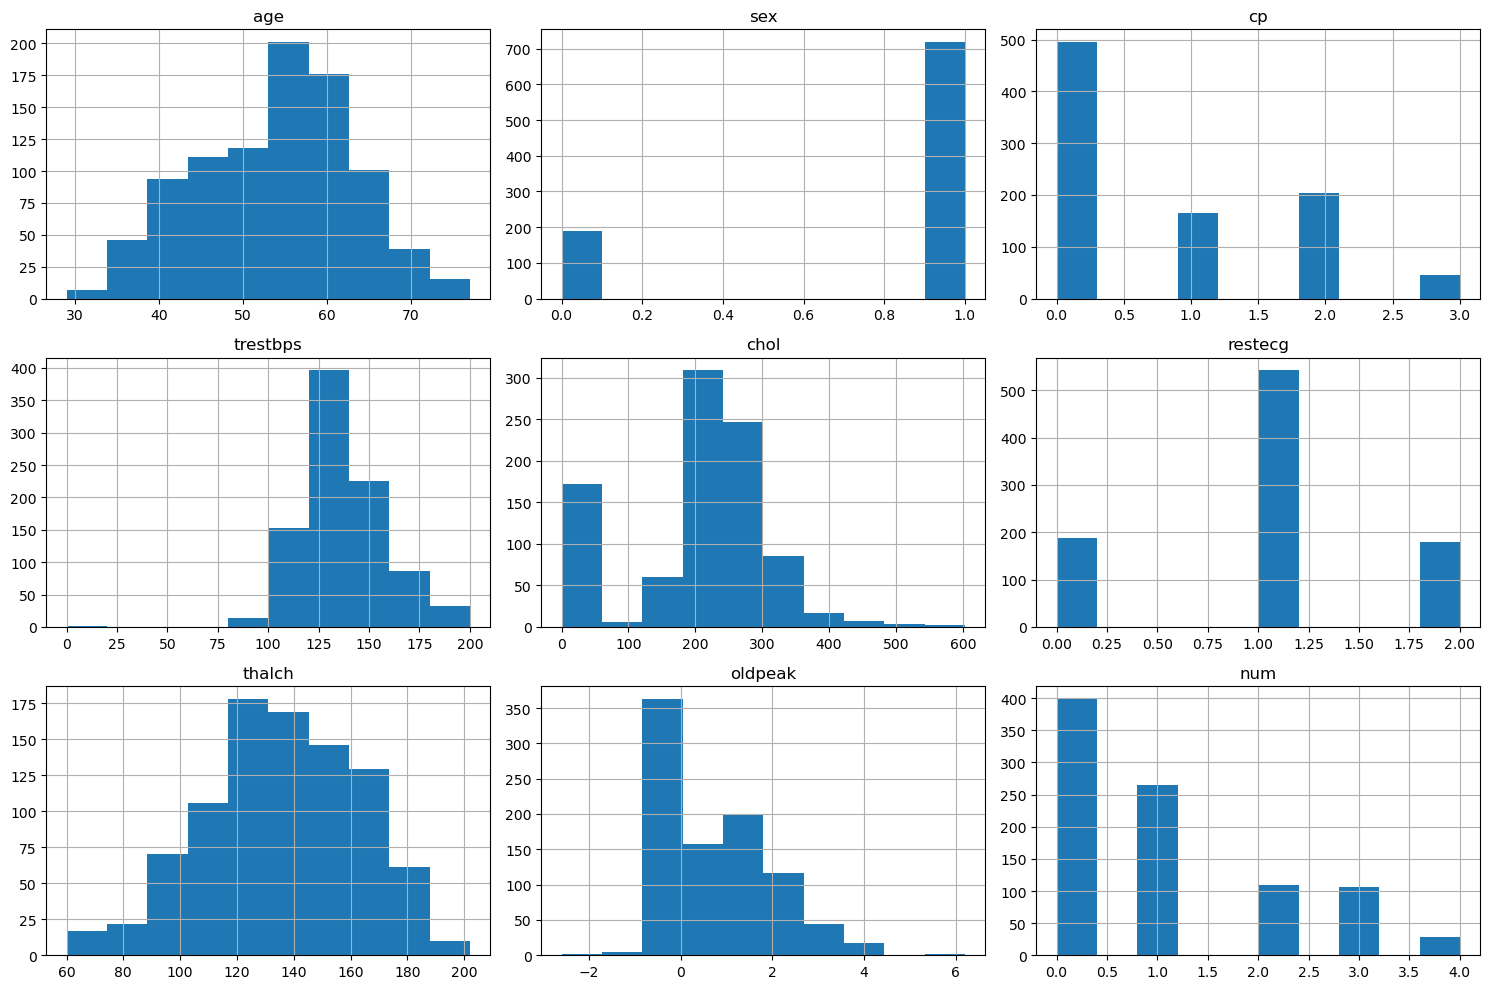

In [36]:
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

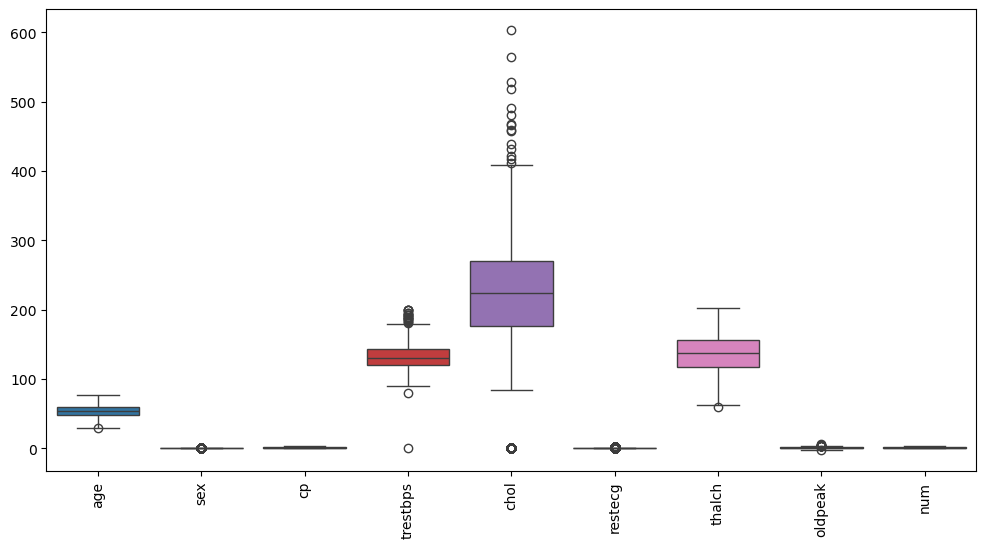

In [37]:
# Boxplot

plt.figure(figsize=(12,6))

sns.boxplot(data=df.select_dtypes(include=np.number))

plt.xticks(rotation=90)

plt.show()

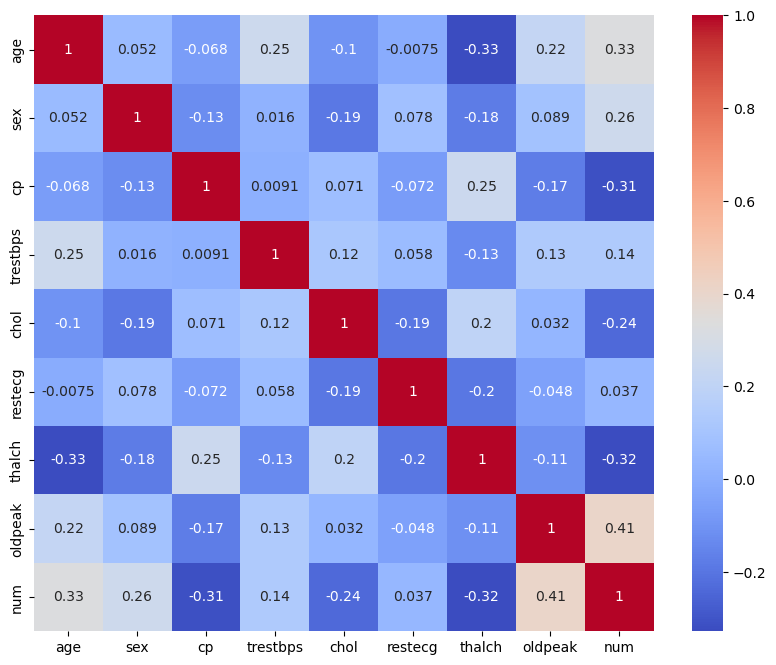

In [38]:
# Core;ation heatmap
plt.figure(figsize=(10,8))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

## Feature engineering

In [41]:
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())
    print(df[col].dtype)


Column: sex
[1 0]
int64

Column: cp
[3 1 0 2]
int64

Column: restecg
[0 1 2]
int64

Column: exang
[False True 'FALSE' 'TURE']
object

Column: slope
['downsloping' 'flat' 'upsloping']
object

Column: thal
['fixed defect' 'normal' 'reversable defect']
object


In [53]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'sex',
    'cp',
    'restecg',
    'exang',
    'slope',
    'thal'
]

for col in categorical_cols:
    df[col] = df[col].astype(str)   # Convert everything to string

    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,True,0,150,1,2.3,0,0,0
1,41,1,1,135,203,False,1,132,1,0.0,1,0,0
2,57,1,0,140,192,False,1,148,1,0.4,1,0,0
3,52,1,3,118,186,False,0,190,1,0.0,1,0,0
4,57,1,0,110,201,False,1,126,3,1.5,1,0,0


In [49]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,True,0,150,1,2.3,0,0,0
1,41,1,1,135,203,False,1,132,1,0.0,1,0,0
2,57,1,0,140,192,False,1,148,1,0.4,1,0,0
3,52,1,3,118,186,False,0,190,1,0.0,1,0,0
4,57,1,0,110,201,False,1,126,3,1.5,1,0,0


In [50]:
print(df.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs            bool
restecg       int64
thalch        int64
exang         int64
oldpeak     float64
slope         int64
thal          int64
num           int64
dtype: object


In [55]:
# Converting target variable
# 0 = No Heart Disease
# 1,2,3,4 = Heart Disease

df["num"] = df["num"].apply(lambda x: 0 if x == 0 else 1)

df["num"].value_counts()

num
1    509
0    399
Name: count, dtype: int64

# Splitting features and values

In [56]:
X = df.drop("num", axis=1)

y = df["num"]

In [58]:
# Train and split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(726, 12)
(182, 12)


In [59]:
#Building decision tree model
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [61]:
# model prediction
y_pred = dt.predict(X_test)

In [62]:
# Model evaluation
accuracy = accuracy_score(y_test,
                          y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.7142857142857143


In [63]:
# Classification report
print(classification_report(y_test,
                            y_pred))

              precision    recall  f1-score   support

           0       0.66      0.72      0.69        80
           1       0.77      0.71      0.73       102

    accuracy                           0.71       182
   macro avg       0.71      0.72      0.71       182
weighted avg       0.72      0.71      0.72       182



# Confusion matrix

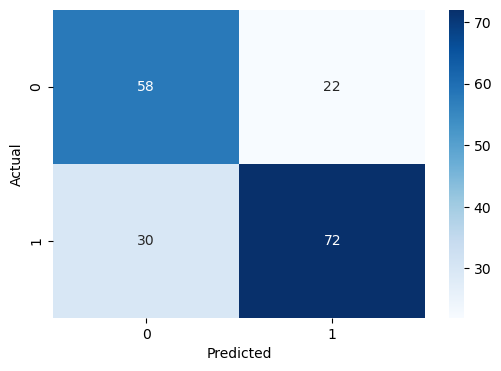

In [64]:
cm = confusion_matrix(y_test,
                      y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [65]:
# Hyper parameter tunning
param_grid = {

    'criterion':['gini',
                 'entropy'],

    'max_depth':[3,
                 5,
                 7,
                 10,
                 15,
                 None],

    'min_samples_split':[2,
                         5,
                         10],

    'min_samples_leaf':[1,
                        2,
                        4]
}

In [66]:
grid = GridSearchCV(

    estimator=DecisionTreeClassifier(
        random_state=42
    ),

    param_grid=param_grid,

    cv=5,

    scoring='accuracy',

    n_jobs=-1
)

grid.fit(X_train,
         y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [67]:
print("Best Parameters :")
print(grid.best_params_)

Best Parameters :
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}


In [68]:
print("Best Score :")
print(grid.best_score_)

Best Score :
0.7685403873405763


## Best decsion tree model

In [69]:
best_dt = grid.best_estimator_

best_dt.fit(X_train,
            y_train)

y_pred_best = best_dt.predict(X_test)

In [70]:
print("Accuracy :",
      accuracy_score(y_test,
                     y_pred_best))

Accuracy : 0.7307692307692307


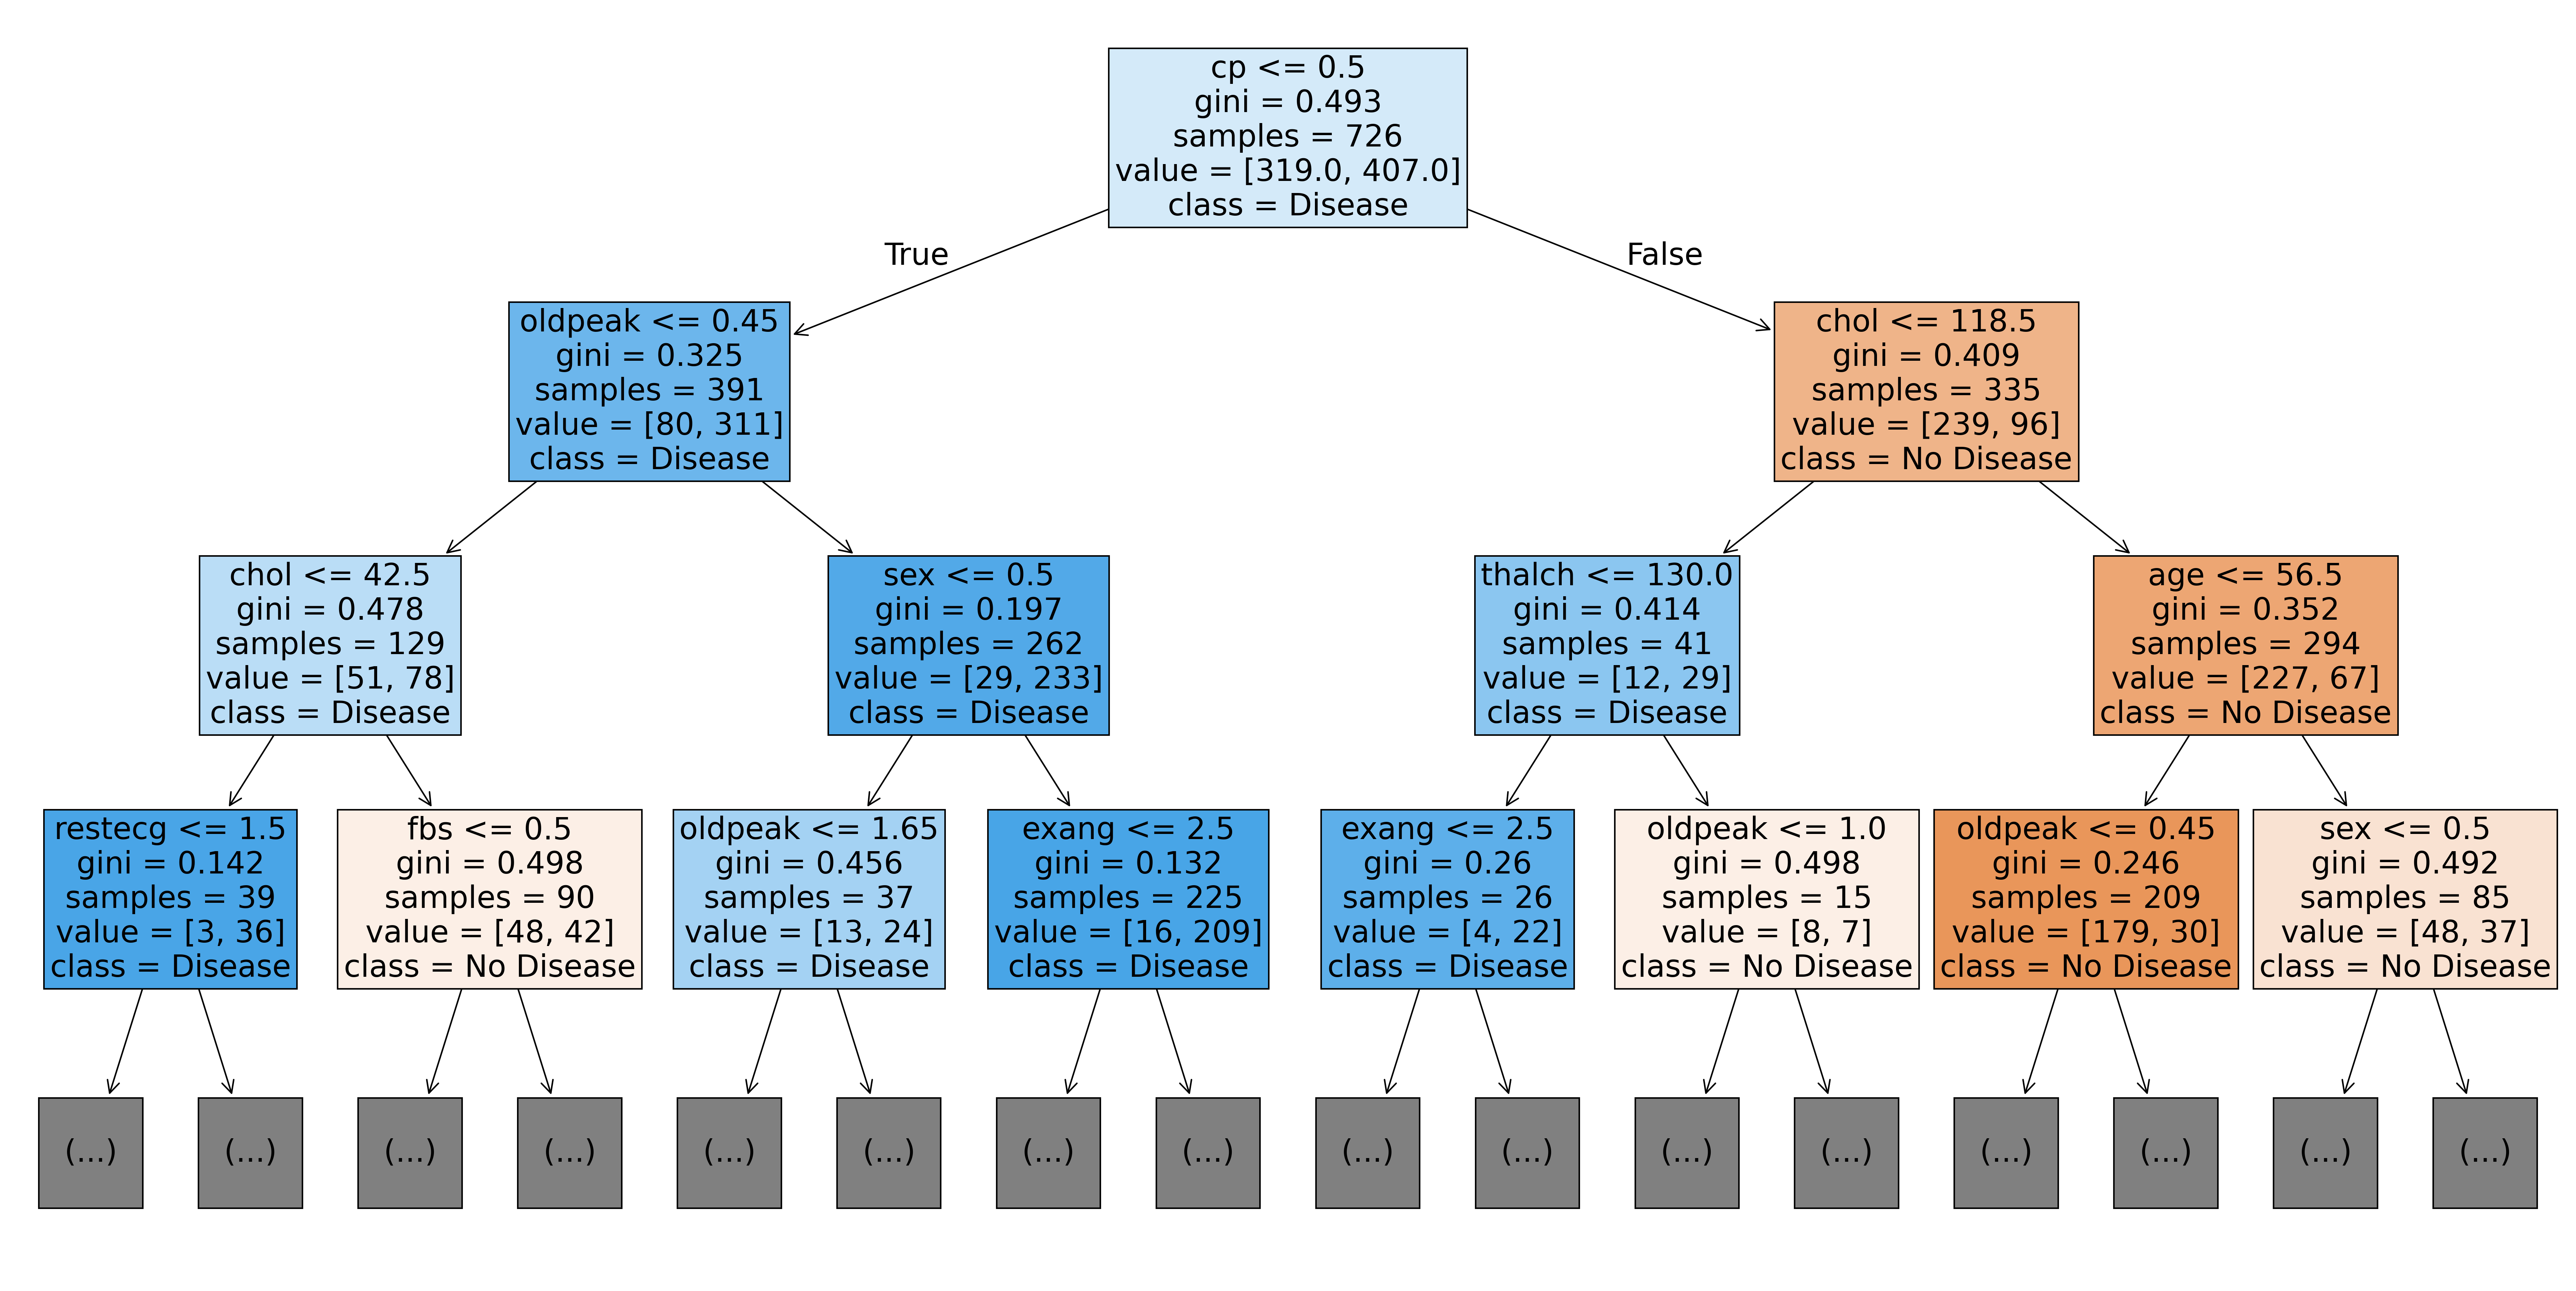

In [79]:
# Visualization decision tree
plt.figure(figsize=(30,15), dpi=300)

plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=["No Disease",
                 "Disease"],
    filled=True,
    fontsize=20,
    max_depth=3
)
plt.show()

In [80]:
# Feature importance
importance = pd.DataFrame({

    'Feature':X.columns,

    'Importance':
    best_dt.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
2,cp,0.475788
4,chol,0.171883
9,oldpeak,0.120307
0,age,0.070979
1,sex,0.052179
7,thalch,0.032262
8,exang,0.030564
5,fbs,0.022044
11,thal,0.020400
6,restecg,0.002488


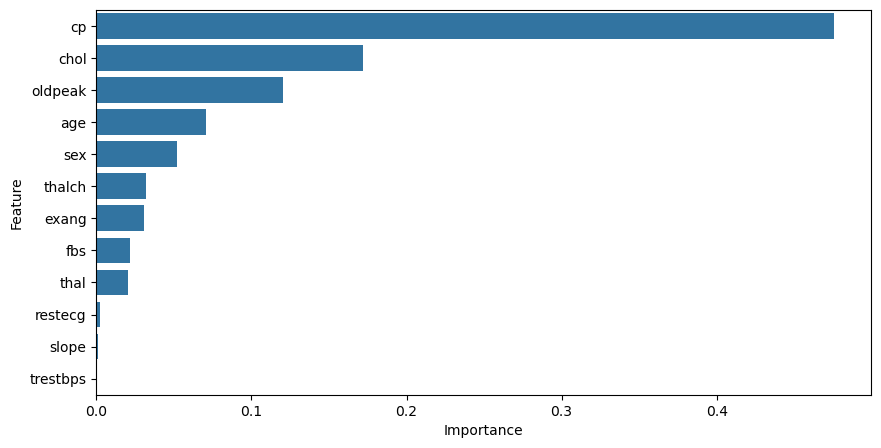

In [81]:
# Feature importance plot
plt.figure(figsize=(10,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.show()

# conclusion

### Findings

The Heart Disease dataset contains 908 patient records.

Missing values in oldpeak were handled using median imputation.

Categorical variables were encoded using Label Encoding.

Decision Tree Classification was applied successfully.

Hyperparameter tuning improved model performance.

Feature importance analysis identified the most influential factors for predicting heart disease.

The model can assist in early identification of heart disease risk.

## 1. What are some common hyperparameters of Decision Tree models, and how do they affect the model's performance?

#### max_depth

Controls the depth of the tree.
    
Higher values may cause overfitting.

#### min_samples_split

Minimum number of samples required to split a node.

Larger values reduce overfitting.

#### min_samples_leaf

Minimum samples required at a leaf node.

Helps create smoother decision boundaries.

##### criterion

Measures quality of split.

Common values: Gini and Entropy.

max_features

Number of features considered at each split.

## 2. What is the difference between Label Encoding and One-Hot Encoding?


#### Label Encoding	
* Converts categories into numbers	
* Uses less memory	
* Suitable for ordinal data	
* May introduce artificial order	
* Example: Male=0, Female=1	

#### One-Hot Encoding
* Creates separate binary columns
* Uses more memory
* Suitable for nominal data
* No ordering introduced
* Male=[1,0], Female=[0,1]